In [3]:
import torch
import ray
import os
import pandas as pd
import numpy as np

from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# Define which slides you want to process here
slide_path = "/mnt/projects/ri_scale/privagams/breast"

/home/jovyan/similarity/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-13 12:34:09,190	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


# Code for similarity taken from silde_embeddings.py

In [51]:
def load_parquet(path): 
    data = pd.read_parquet(path)
    return data

def load_embeddings(slide_path, file_name):
    dirs_to_process = sorted([
        d for d in os.listdir(slide_path) 
        if os.path.isdir(os.path.join(slide_path, d)) and not d.startswith(".")
    ])
    embeddings: List[torch.Tensor] = []
    labels = []

    for dir in dirs_to_process:
        embeddings_path = os.path.join(slide_path, dir, file_name)
        tensor = torch.tensor(load_parquet(embeddings_path).embedding[0], dtype=torch.float32)
        embeddings.append(tensor)
        labels.append(dir)
    
    emb_matrix = torch.stack(embeddings, dim=0)

    return (emb_matrix, labels)

def save_simmilarity(sim_matrix, labels, name):

    # making flash as rows and midi as cols
    keep_rows = [label.startswith("FLASH") for label in labels]
    keep_cols = [label.startswith("MIDI") for label in labels]
    x_labels = [label for label in labels if label.startswith("MIDI")]
    y_labels = [label for label in labels if label.startswith("FLASH")]

    sim_matrix = sim_matrix[keep_rows, :]
    sim_matrix = sim_matrix[:, keep_cols]

    df = pd.DataFrame(sim_matrix, index=y_labels, columns=x_labels)
    df.to_csv(os.path.join(slide_path, f"{name}_similarity.csv"), float_format="%.12f", index=True)

    diagonal_values = torch.diag(sim_matrix)
    row_max_values = torch.max(sim_matrix, dim=1).values
    is_diagonal_max = (diagonal_values == row_max_values)
    count = torch.sum(is_diagonal_max).item() 

    print(f"Number of MIDI/FLASH matches for {name} is {count}")


    plt.figure(figsize=(10, 8))
    sns.heatmap(
        sim_matrix,
        xticklabels=x_labels,
        yticklabels=y_labels,
        cmap="viridis",
        annot=True,
        fmt=".2f",                    
        linewidths=0.5,
        linecolor="gray",
        cbar_kws={"label": f"{name} similarity"},
        annot_kws={"fontsize": 10}
    )
    plt.title(f"Pairwise {name} similarity of slide embeddings")
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(slide_path, f"{name}_similarity_heatmap.png"), dpi=300)

def cos_simmilarity(slide_path, file_name):
    emb_matrix, labels = load_embeddings(slide_path, file_name)
    X_norm = F.normalize(emb_matrix, p=2, dim=1)
    cosine_sim = X_norm @ X_norm.T
    save_simmilarity(cosine_sim, labels, f"cos_{file_name}")

def l1_simmilarity(slide_path, file_name):
    emb_matrix, labels = load_embeddings(slide_path, file_name)
    l1_distance_matrix = torch.cdist(emb_matrix, emb_matrix, p=1)

    D_min = l1_distance_matrix.min()
    D_max = l1_distance_matrix.max()

    # 2. Normalizace matice na rozsah [0, 1]
    # (Odečteme minimum a vydělíme rozsahem)
    D_range = D_max - D_min
    # Ošetření případu, kdy D_range je nula (např. matice plná stejných hodnot)
    if D_range == 0:
        similarity_matrix = torch.ones_like(l1_distance_matrix)
    else:
        D_norm = (l1_distance_matrix - D_min) / D_range
        
        # 3. Inverze (Odečtení od 1)
        similarity_matrix = 1 - D_norm

    save_simmilarity(similarity_matrix, labels, f"L1_{file_name}")

def l2_simmilarity(slide_path, file_name):
    emb_matrix, labels = load_embeddings(slide_path, file_name)
    l2_distance_matrix = torch.cdist(emb_matrix, emb_matrix, p=2)

    D_min = l2_distance_matrix.min()
    D_max = l2_distance_matrix.max()

    # 2. Normalizace matice na rozsah [0, 1]
    # (Odečteme minimum a vydělíme rozsahem)
    D_range = D_max - D_min
    # Ošetření případu, kdy D_range je nula (např. matice plná stejných hodnot)
    if D_range == 0:
        similarity_matrix = torch.ones_like(l2_distance_matrix)
    else:
        D_norm = (l2_distance_matrix - D_min) / D_range
        
        # 3. Inverze (Odečtení od 1)
        similarity_matrix = 1 - D_norm

    save_simmilarity(similarity_matrix, labels, f"L2_{file_name}")

#### generating cos, l1 and l2 similarity for certain slide paths

Number of MIDI/FLASH matches for cos_slide.parquet is 1
Number of MIDI/FLASH matches for L1_slide.parquet is 1
Number of MIDI/FLASH matches for L2_slide.parquet is 1


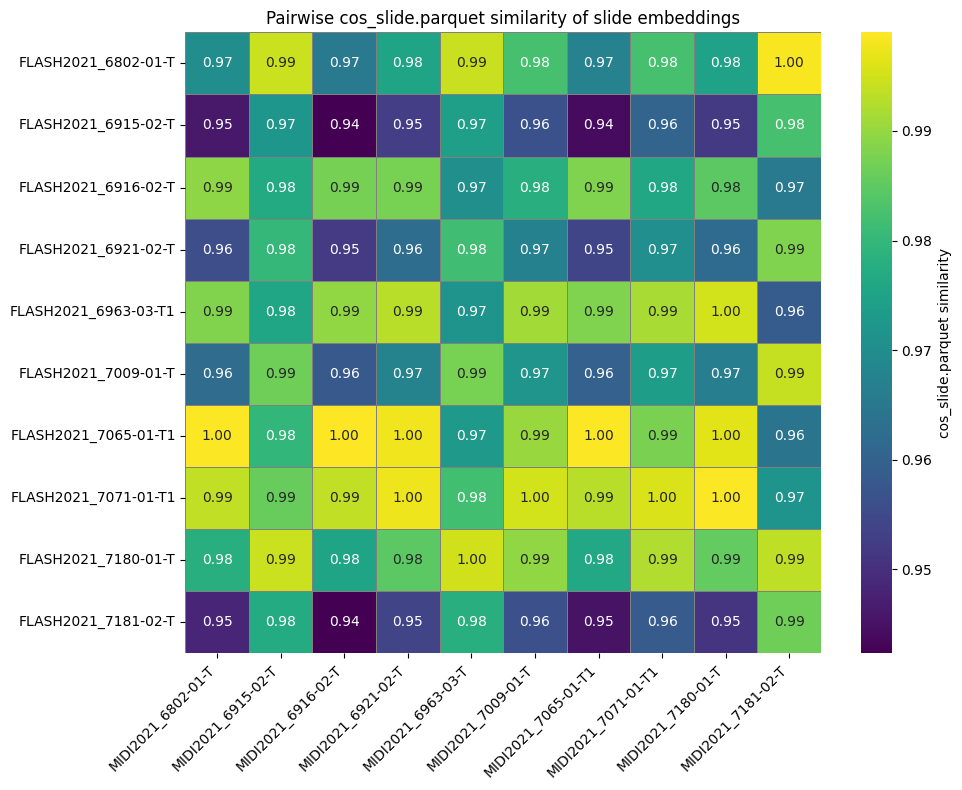

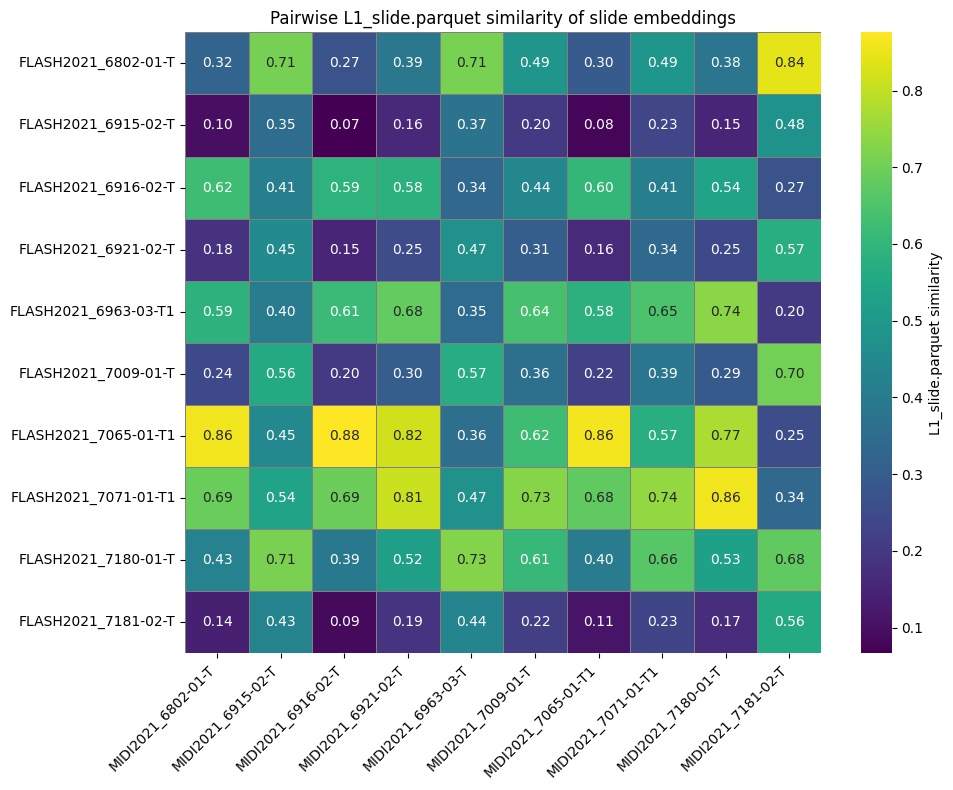

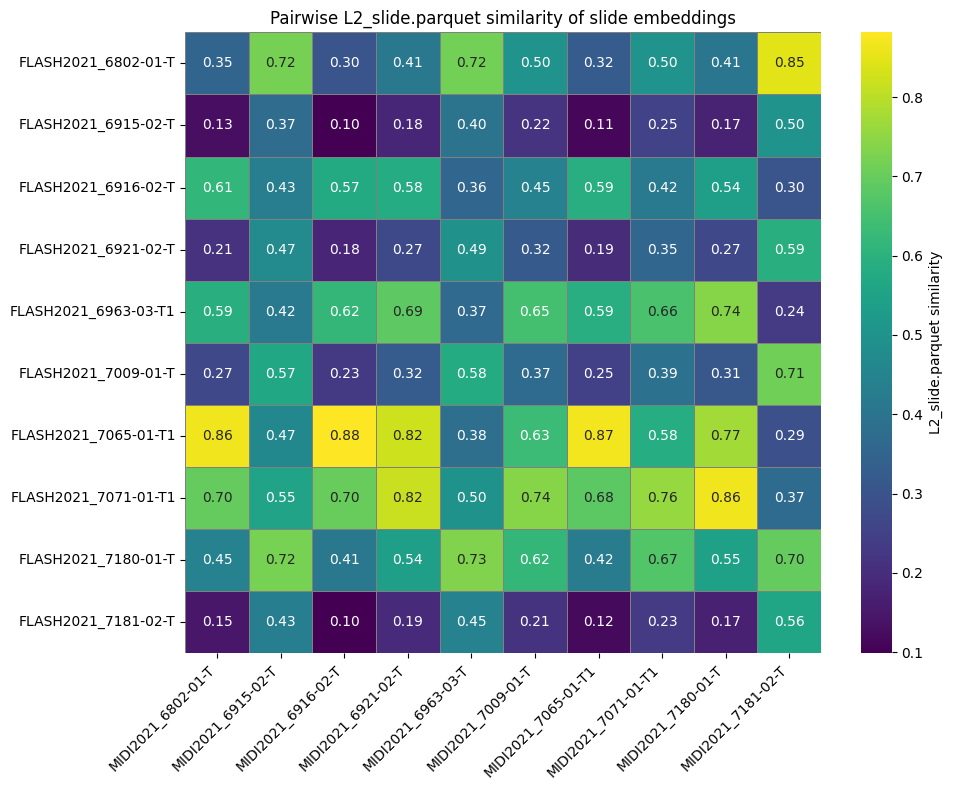

In [ ]:
cos_simmilarity(slide_path, "slide.parquet")
l1_simmilarity(slide_path, "slide.parquet")
l2_simmilarity(slide_path, "slide.parquet")

# Code for playing directly with tiles embeddings

In [3]:
def load_parquet(path): 
    data = pd.read_parquet(path)
    return data

def load_tiles_embeddings(slide_path):
    dirs_to_process = sorted([
        d for d in os.listdir(slide_path) 
        if os.path.isdir(os.path.join(slide_path, d)) and not d.startswith(".")
    ])
    embeddings: List[List[torch.Tensor]] = []
    labels = []

    for dir in dirs_to_process:
        embeddings_path = os.path.join(slide_path, dir, "tiles.parquet")
        embedding_array = np.array(load_parquet(embeddings_path).embedding.tolist())
        embedding_matrix = torch.tensor(embedding_array, dtype=torch.float32)
        embeddings.append(embedding_matrix)
        labels.append(dir)
    

    return (embeddings, labels)

#### getting tiles embedding for each slide in slide_path

In [4]:
matrix, labels = load_tiles_embeddings(slide_path)

#### generating mean of all tiles embedding to act as slide embedding

In [28]:
for i in range(len(labels)):
    wsi_embedding = torch.mean(matrix[i], dim=0)
    label = labels[i]
    output_df = pd.DataFrame({
        'slide_id': label,
        'embedding': [wsi_embedding.tolist()],
    })
    output_df.to_parquet(f"{slide_path}/{label}/slide_mean.parquet", index=False)

Number of MIDI/FLASH matches for cos_slide_mean.parquet is 10
Number of MIDI/FLASH matches for L1_slide_mean.parquet is 10
Number of MIDI/FLASH matches for L2_slide_mean.parquet is 9


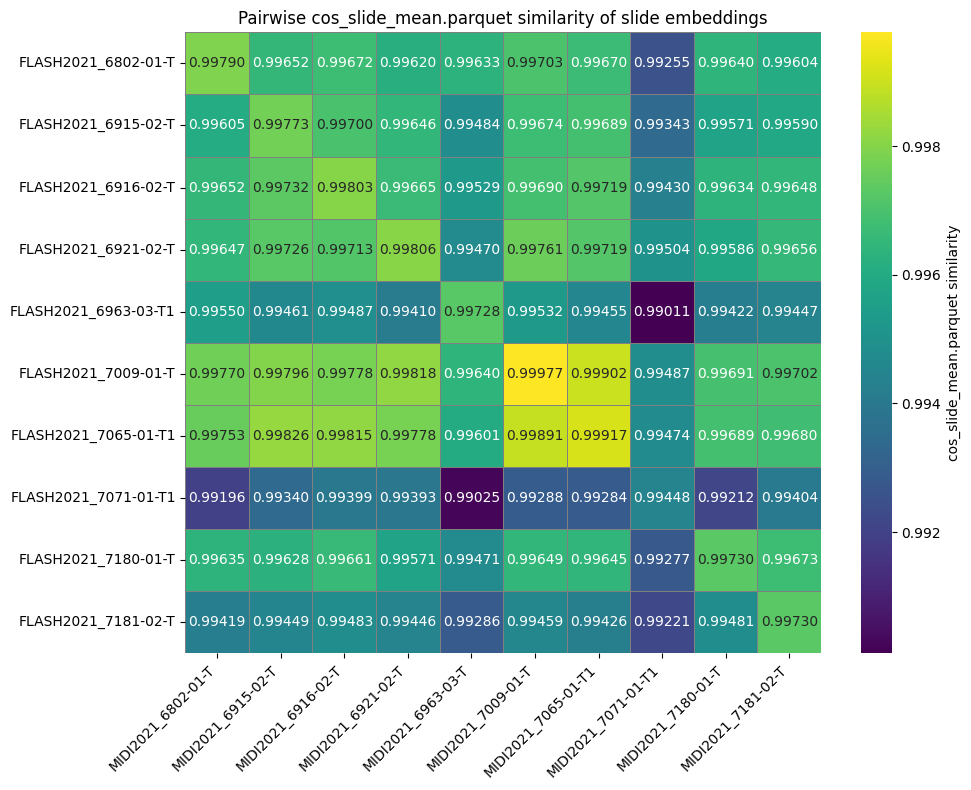

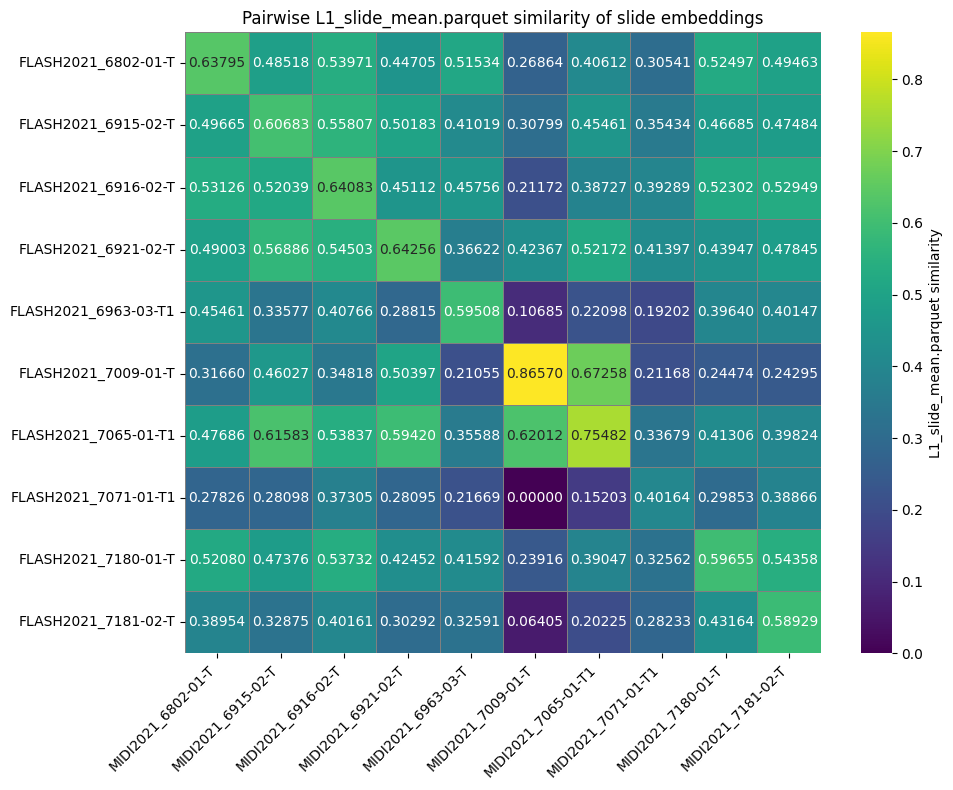

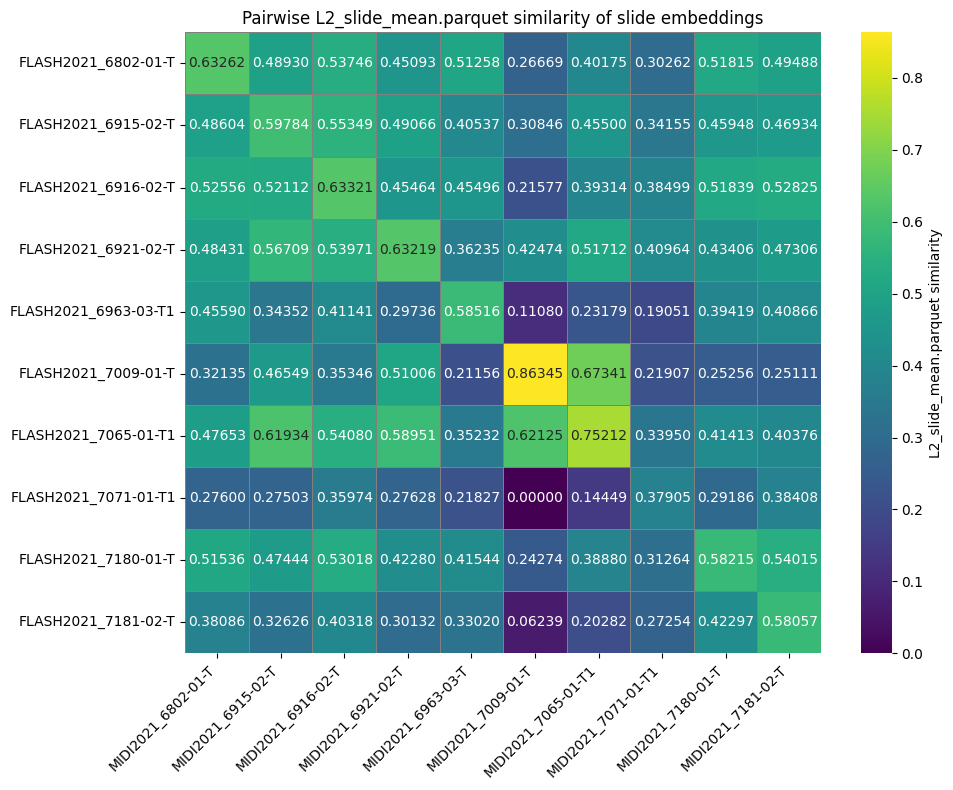

In [ ]:
cos_simmilarity(slide_path, "slide_mean.parquet")
l1_simmilarity(slide_path, "slide_mean.parquet")
l2_simmilarity(slide_path, "slide_mean.parquet")

### Statistical pooling

In [52]:
for i in range(len(labels)):
    mean_vector = torch.mean(matrix[i], dim=0)
    std_dev_vector = torch.std(matrix[i], dim=0)
    wsi_embedding = torch.cat((mean_vector, std_dev_vector), dim=0)

    label = labels[i]
    output_df = pd.DataFrame({
        'slide_id': label,
        'embedding': [wsi_embedding.tolist()],
    })
    output_df.to_parquet(f"{slide_path}/{label}/slide_statistic.parquet", index=False)



Number of MIDI/FLASH matches for cos_slide_statistic.parquet is 9
Number of MIDI/FLASH matches for L1_slide_statistic.parquet is 9
Number of MIDI/FLASH matches for L2_slide_statistic.parquet is 9


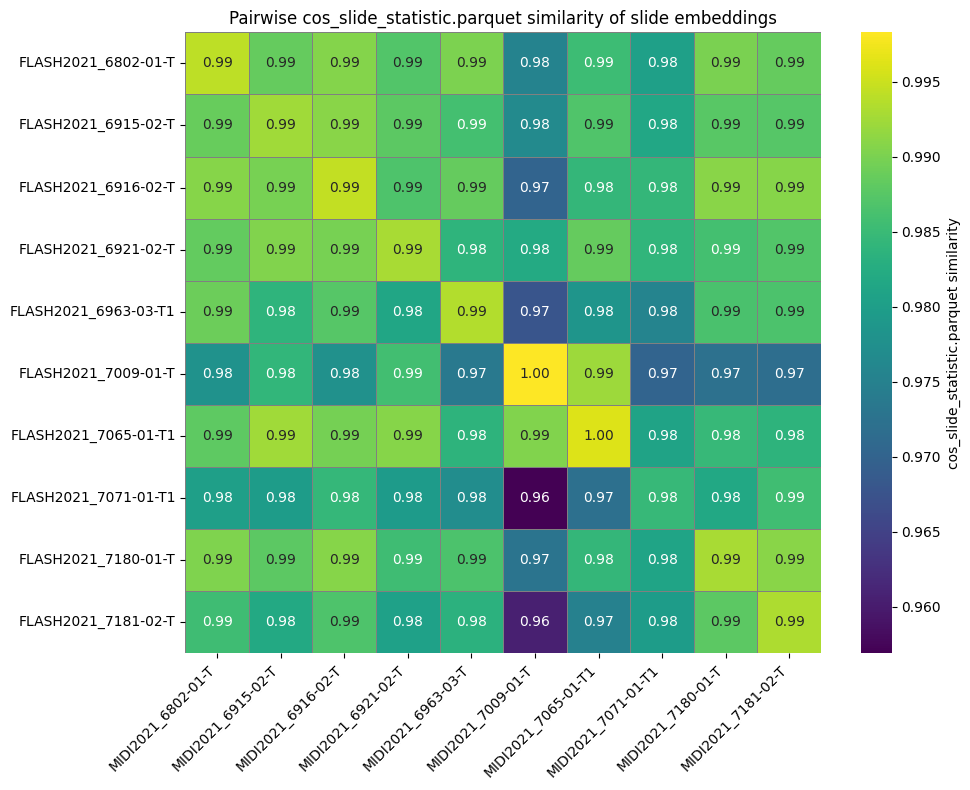

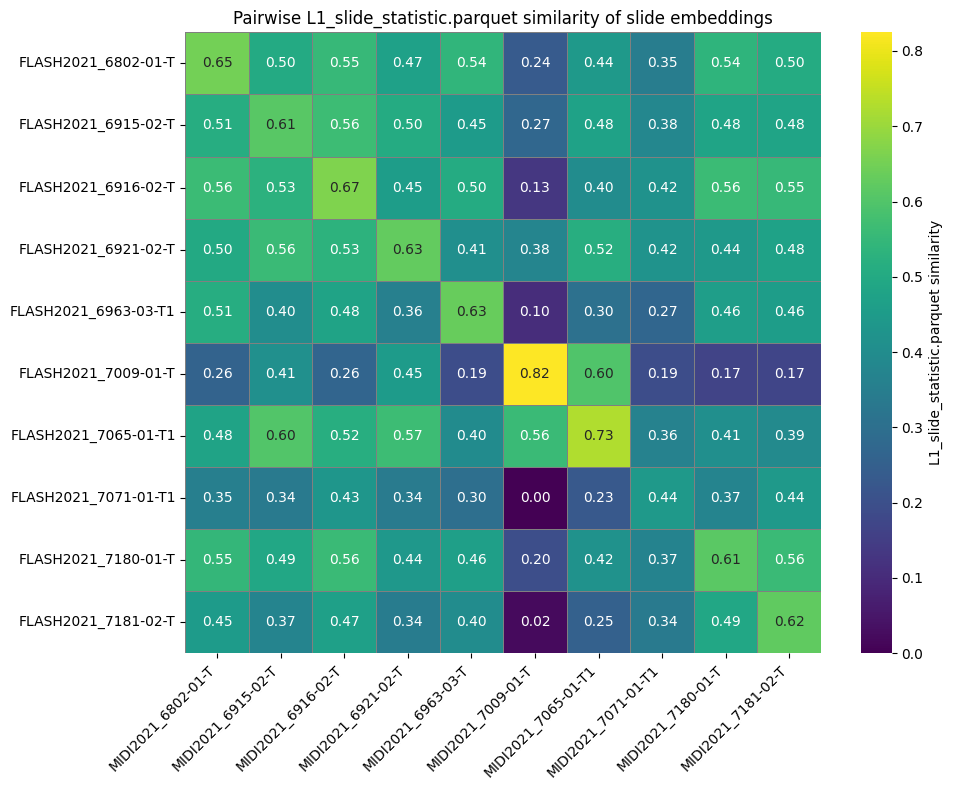

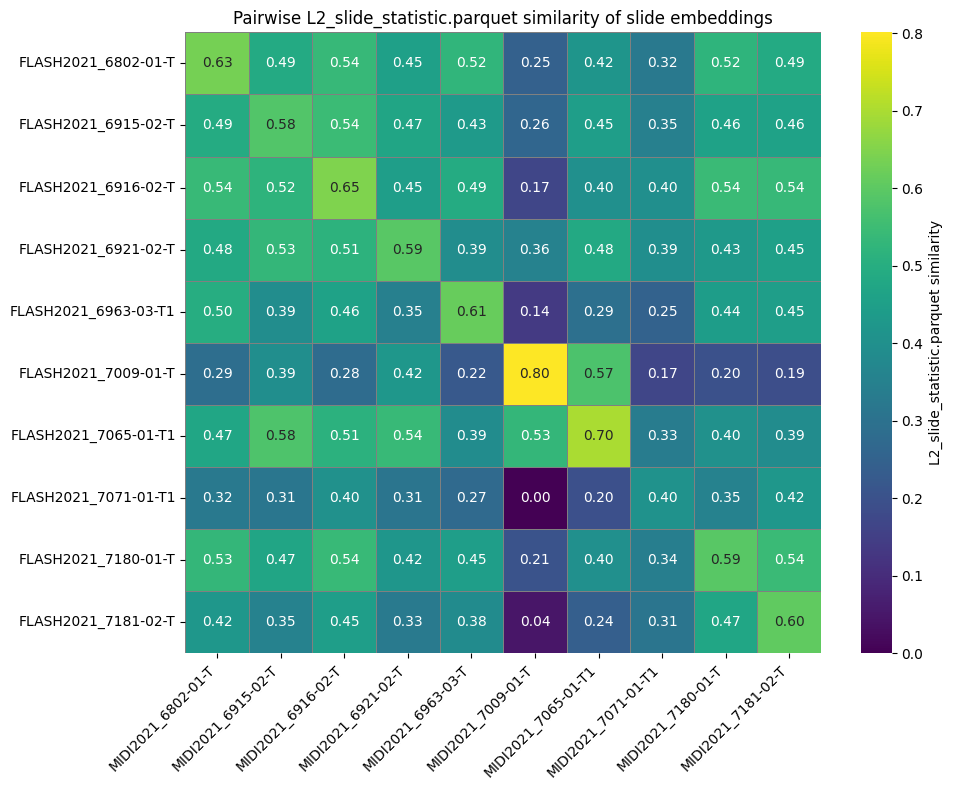

In [ ]:
cos_simmilarity(slide_path, "slide_statistic.parquet")
l1_simmilarity(slide_path, "slide_statistic.parquet")
l2_simmilarity(slide_path, "slide_statistic.parquet")